# Citi Bike

<img src="https://substackcdn.com/image/fetch/$s_!JIfm!,w_1200,h_675,c_fill,f_jpg,q_auto:good,fl_progressive:steep,g_auto/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F1c4d16d7-0f9d-4ada-bfe8-232db71b6069_3800x2533.jpeg" width="400">

Citi Bike es un sistema privado de bicicletas compartidas de Nueva York que presta servicio en los distritos neoyorquinos del Bronx, Brooklyn, Manhattan y Queens, así como en Jersey City y Hoboken, en Nueva Jersey.

Este proyecto tiene como objetivo analizar el comportamiento y la eficiencia operativa del sistema de bicicletas compartidas Citi Bike.

## Preparacion y carga

In [3]:
import pandas as pd

# 1. Carga
url = "https://raw.githubusercontent.com/mamaggie/TutorialProjects/main/data/citi_bike_trip_data.csv"
df = pd.read_csv(url)

In [4]:
df.head()

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender
0,326,2013-10-01 00:01:08,2013-10-01 00:06:34,239,Willoughby St & Fleet St,40.691966,-73.981302,366,Clinton Ave & Myrtle Ave,40.693261,-73.968896,16052,Subscriber,1982,1
1,729,2013-10-01 00:01:21,2013-10-01 00:13:30,322,Clinton St & Tillary St,40.696192,-73.991218,398,Atlantic Ave & Furman St,40.691652,-73.999979,19412,Customer,\N,0
2,520,2013-10-01 00:01:24,2013-10-01 00:10:04,174,E 25 St & 1 Ave,40.738177,-73.977387,403,E 2 St & 2 Ave,40.725029,-73.990697,19645,Subscriber,1984,1
3,281,2013-10-01 00:01:25,2013-10-01 00:06:06,430,York St & Jay St,40.701485,-73.986569,323,Lawrence St & Willoughby St,40.692362,-73.986317,16992,Subscriber,1985,1
4,196,2013-10-01 00:01:27,2013-10-01 00:04:43,403,E 2 St & 2 Ave,40.725029,-73.990697,401,Allen St & Rivington St,40.720196,-73.989978,15690,Subscriber,1986,1


In [10]:
# 2. Conversión a tipos adecuados
# Es crucial convertir los tiempos a datetime para poder extraer horas y días
df['starttime'] = pd.to_datetime(df['starttime'])
df['stoptime'] = pd.to_datetime(df['stoptime'])

In [16]:
#revisamos si hay datos duplicados
df.duplicated().sum()

np.int64(0)

In [14]:
# Verificamos si hay valores nulos importantes
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
tripduration               0
starttime                  0
stoptime                   0
start station id           0
start station name         0
start station latitude     0
start station longitude    0
end station id             0
end station name           0
end station latitude       0
end station longitude      0
bikeid                     0
usertype                   0
birth year                 0
gender                     0
dtype: int64


In [17]:
df.shape

(40575, 15)

## Preparación del Análisis Temporal

In [18]:
# Extracción de características temporales

# Creamos una nueva columna llamada "day_of_week" con el nombre del día (Monday, Tuesday, etc.) extraído de starttime
df['day_of_week'] = df['starttime'].dt.day_name()

# Creamos una nueva columna llamada "hour" con la hora (0–23) extraída de starttime.
df['hour'] = df['starttime'].dt.hour

In [28]:
# Crear una categoría para 'hora punta' (ejemplo: 7-9h y 17-19h)
def categorize_hour(hour):
    if 7 <= hour <= 9 or 17 <= hour <= 19:
        return 'Hora Punta'
    else:
        return 'Resto del día'

df['periodo'] = df['hour'].apply(categorize_hour)

In [29]:
df.head()

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,day_of_week,hour,periodo
0,326,2013-10-01 00:01:08,2013-10-01 00:06:34,239,Willoughby St & Fleet St,40.691966,-73.981302,366,Clinton Ave & Myrtle Ave,40.693261,-73.968896,16052,Subscriber,1982,1,Tuesday,0,Resto del día
1,729,2013-10-01 00:01:21,2013-10-01 00:13:30,322,Clinton St & Tillary St,40.696192,-73.991218,398,Atlantic Ave & Furman St,40.691652,-73.999979,19412,Customer,\N,0,Tuesday,0,Resto del día
2,520,2013-10-01 00:01:24,2013-10-01 00:10:04,174,E 25 St & 1 Ave,40.738177,-73.977387,403,E 2 St & 2 Ave,40.725029,-73.990697,19645,Subscriber,1984,1,Tuesday,0,Resto del día
3,281,2013-10-01 00:01:25,2013-10-01 00:06:06,430,York St & Jay St,40.701485,-73.986569,323,Lawrence St & Willoughby St,40.692362,-73.986317,16992,Subscriber,1985,1,Tuesday,0,Resto del día
4,196,2013-10-01 00:01:27,2013-10-01 00:04:43,403,E 2 St & 2 Ave,40.725029,-73.990697,401,Allen St & Rivington St,40.720196,-73.989978,15690,Subscriber,1986,1,Tuesday,0,Resto del día


## Ejecución del Análisis Temporal (Objetivo 3)

### ¿Qué analizaremos con esto?
- Horas Pico: Analizaremos dos picos claros (probablemente entre 7-9 am y 5-7 pm). Esto nos dará la respuesta para el Objetivo 1 (Optimización Operativa), ya que nos dirá cuándo debemos tener más bicicletas en las estaciones principales.

- Patrones semanales: Analizaremos si el uso es más "laboral" (horas para salir a trabajar) o "recreativo" (horas de hocio). Esto es vital para el Objetivo 2, ya que los suscriptores suelen usar la bici para ir al trabajo y los clientes ocasionales para pasear.

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")

C:\Users\DELL\AppData\Local\Temp\ipykernel_3600\1678541319.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour', data=df, palette='viridis')


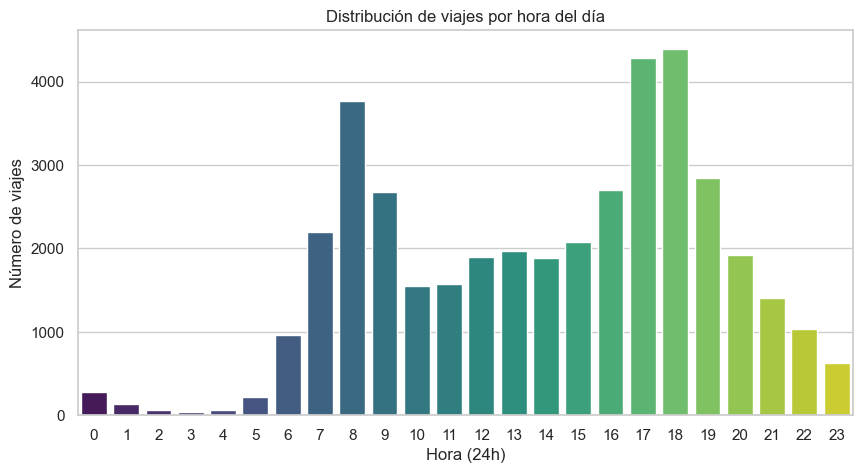

In [32]:
# Gráfico 1: Demanda por hora del día
plt.figure(figsize=(10, 5))
sns.countplot(x='hour', data=df, palette='viridis')
plt.title('Distribución de viajes por hora del día')
plt.xlabel('Hora (24h)')
plt.ylabel('Número de viajes')
plt.show()

## Análisis comparativo (Objetivo 2: Suscriptores vs. Clientes)
Teniendo en cuenta que esta DataSet contiene los datos de un solo día (24h), vamos a ver quiénes son los que están usando el sistema en cada hora punta.

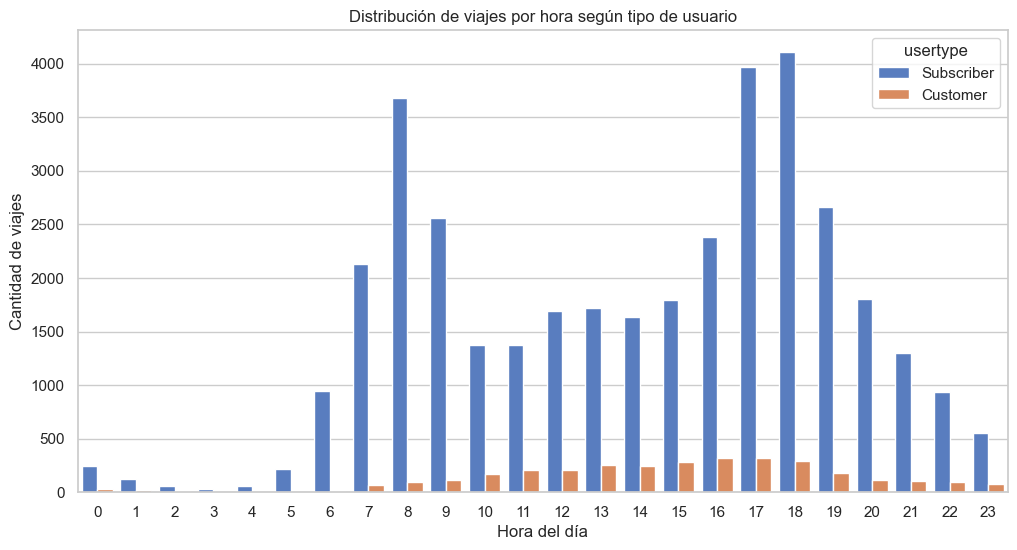

In [34]:
# Comparativa de horas por tipo de usuario
plt.figure(figsize=(12, 6))
sns.countplot(x='hour', hue='usertype', data=df, palette='muted')
plt.title('Distribución de viajes por hora según tipo de usuario')
plt.xlabel('Hora del día')
plt.ylabel('Cantidad de viajes')
plt.show()

### ¿Qué podemos percatar con este grafico?
- Los Suscriptores (Commuters): Se nota una concentración masiva de este grupo en las horas punta (8:00 AM y 6:00 PM), lo cual confirma su uso como transporte diario al trabajo.

- Clientes (Ocasionales): A menudo presentan un comportamiento más plano o un pico a mitad del día o tarde-noche, lo que sugiere un uso recreativo o turístico.

In [35]:
# Comparativa de duración media por tipo de usuario
duracion_media = df.groupby('usertype')['tripduration'].mean()
print("Duración media del viaje por tipo de usuario:")
print(duracion_media)

Duración media del viaje por tipo de usuario:
usertype
Customer      1370.807859
Subscriber     774.908283
Name: tripduration, dtype: float64


## Análisis de Estaciones (Objetivo 1) - "Cuellos de botella"
Ahora pasaremos a la parte operativa. Para que el sistema funcione, las bicicletas deben estar disponibles donde los suscriptores las necesitan. Vamos a identificar las estaciones críticas.

Para esto, vamos  a buscar las estaciones con mayor volumen de salidasy llegadas.

In [37]:
# Top 10 estaciones con mayor flujo de salida
top_start = df['start station name'].value_counts().head(10)

# Top 10 estaciones con mayor flujo de llegada
top_end = df['end station name'].value_counts().head(10)

print("Top 10 Estaciones de Salida:")
print(top_start)

print("\nTop 10 Estaciones de Llegada:")
print(top_end)

Top 10 Estaciones de Salida:
start station name
Pershing Square N           603
W 20 St & 11 Ave            443
Lafayette St & E 8 St       379
Broadway & E 14 St          364
E 17 St & Broadway          347
University Pl & E 14 St     343
E 43 St & Vanderbilt Ave    341
W 21 St & 6 Ave             331
W 33 St & 7 Ave             330
West St & Chambers St       329
Name: count, dtype: int64

Top 10 Estaciones de Llegada:
end station name
W 20 St & 11 Ave            429
8 Ave & W 31 St             420
Pershing Square N           408
E 17 St & Broadway          403
Lafayette St & E 8 St       391
West St & Chambers St       350
Broadway & W 24 St          337
Broadway & E 14 St          328
W 21 St & 6 Ave             324
E 43 St & Vanderbilt Ave    323
Name: count, dtype: int64


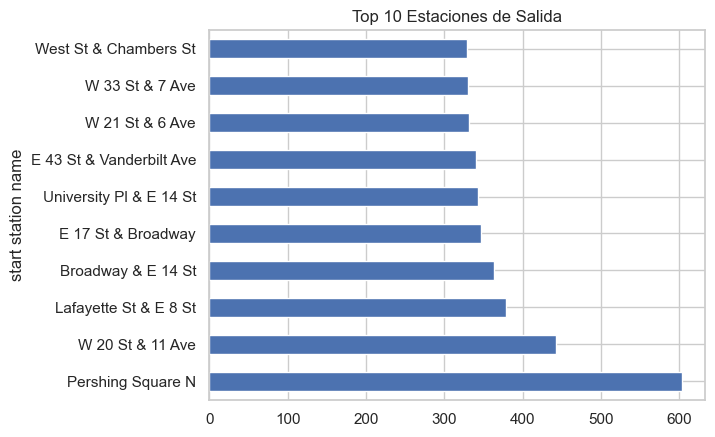

In [ ]:
#Visualización rápida
top_start.plot(kind='barh', title='Top 10 Estaciones de Salida')
plt.show()

### Análisis de Desequilibrio Operativo
En este paso calculamos el flujo neto para identificar dónde el equipo de mantenimiento debe priorizar la redistribución.

In [39]:
# Crear tablas de conteo por estación
salidas = df['start station name'].value_counts()
llegadas = df['end station name'].value_counts()

# Unir en un DataFrame
flujo_df = pd.DataFrame({'Salidas': salidas, 'Llegadas': llegadas})
flujo_df = flujo_df.fillna(0) # Si una estación no tuvo salidas/llegadas, ponemos 0

# Calcular el balance: Salidas - Llegadas
# Un valor POSITIVO indica que la estación tiende a vaciarse (más salidas)
# Un valor NEGATIVO indica que la estación tiende a llenarse (más llegadas)
flujo_df['Balance'] = flujo_df['Salidas'] - flujo_df['Llegadas']

# Ordenar por el balance más crítico
print("Top 10 estaciones con mayor desequilibrio (Necesitan atención):")
print(flujo_df.sort_values(by='Balance', ascending=False).head(10))

Top 10 estaciones con mayor desequilibrio (Necesitan atención):
                        Salidas  Llegadas  Balance
Pershing Square N         603.0       408    195.0
W 33 St & 7 Ave           330.0       214    116.0
W 41 St & 8 Ave           324.0       229     95.0
Broadway & W 39 St        158.0        94     64.0
E 6 St & Avenue B         185.0       124     61.0
Pershing Square S         165.0       106     59.0
W 45 St & 8 Ave           228.0       175     53.0
Barclay St & Church St    275.0       231     44.0
Broadway & W 41 St        266.0       225     41.0
Broadway & W 55 St        197.0       157     40.0
